In [1]:
import rioxarray
import xarray as xr

# Get data from seNorge

[seNorge](https://www.senorge.no/) provides a wide range of historic weather and climate data at different time resolutions. Most of these datasets are also available via the GTS API, which provides more fine-grained control over query parameters (see [this](https://github.com/NIVANorge/catchment_processing_workflows/blob/main/notebooks/nve_gts_api_example.ipynb) notebook). However, if you want to download gridded data at 1 km resolution, it's often easier to access the netCDFs directly.

netCDFs for seNorge are hosted by met.no on Thredds. The main dataset page is:

https://thredds.met.no/thredds/projects/senorge.html

Within this are various folders containing seNorge datasets with different levels of time aggregation. For example, long term annual runoff is here:

https://thredds.met.no/thredds/catalog/senorge/seNorge_2018/aggregated_products/v22_09/rr/catalog.html?dataset=senorge/seNorge_2018/aggregated_products/v22_09/rr/seNorge2018_normals_prcptot_1991-2020_yearly.nc

## 1. Accessing data from Python

From the landing page for any dataset, click on the OPeNDAP link. At the top of the page, you will see a field named `Data URL` that can be used to access the dataset. For example, for long term annual runoff, the URL is:

    https://thredds.met.no/thredds/dodsC/senorge/seNorge_2018/aggregated_products/v22_09/rr/seNorge2018_normals_prcptot_1991-2020_yearly.nc

Datasets on Thredds should be named consistently, making it easy to build data URLs from you code.



In [2]:
# Read data
url = "https://thredds.met.no/thredds/dodsC/senorge/seNorge_2018/aggregated_products/rr/seNorge2018_rr_normal_1991_2020_yearly.nc"
ds = xr.open_dataset(url)
ds

<xarray.Dataset> Size: 22MB
Dimensions:      (time: 1, time_bnds: 2, Y: 1550, X: 1195)
Coordinates:
    time_bnds    (time, time_bnds) datetime64[ns] 16B ...
  * X            (X) float64 10kB -7.45e+04 -7.35e+04 ... 1.118e+06 1.12e+06
  * Y            (Y) float64 12kB 8e+06 7.998e+06 ... 6.452e+06 6.45e+06
  * time         (time) datetime64[ns] 8B 1991-01-01T06:00:00
    lat          (Y, X) float32 7MB ...
    lon          (Y, X) float32 7MB ...
Data variables:
    UTM_Zone_33  float64 8B ...
    rr           (time, Y, X) float32 7MB ...
Attributes: (12/17)
    CDI:                             Climate Data Interface version 2.0.5 (ht...
    Conventions:                     CF-1.7
    source:                          MET Norway
    institution:                     Norwegian Meteorological Institute, MET ...
    creator_url:                     met.no
    geospatial_lat_min:              57.8
    ...                              ...
    CDO:                             Climate Data Operators version 2.0.5 (ht...
    title:                           aggregated_rr_seNorge2018_v23_11
    summary:                         Precipitation amount yearly normal 1991-...
    history:                         Tue Dec  5 07:58:23 2023: ncatted -O -a ...
    NCO:                             netCDF Operators version 5.1.0 (Homepage...
    DODS_EXTRA.Unlimited_Dimension:  time

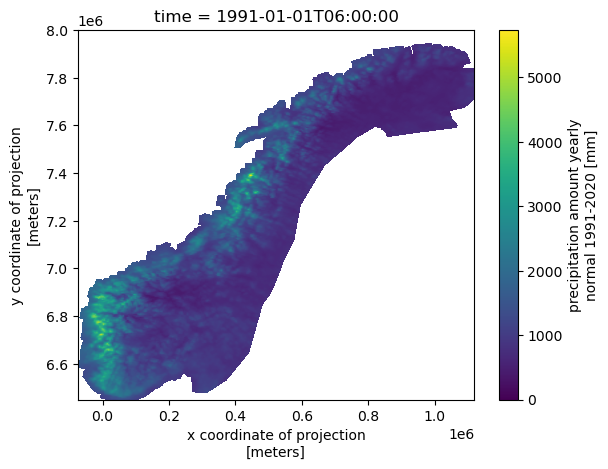

In [3]:
# Simple plot
ds.rr.isel(time=0).plot()

## 2. Save data to GeoTIFF

Sometimes it is convenient to save data from netCDFs as GeoTIFFs e.g. for use in desktop GIS. The code below provides a simple way to do this.

In [4]:
# Select slice
da = ds["rr"].isel(time=0)

# Tidy
da = da.rio.set_spatial_dims(x_dim="X", y_dim="Y")
da = da.sortby("Y", ascending=False)
da = da.rio.write_crs("EPSG:32633")

# Save
da.rio.to_raster(
    "senorge_rr.tif",
    compress="LZW",
    tiled=True,
    blockxsize=512,
    blockysize=512
)